In [76]:
import pandas as pd

In [77]:
df= pd.read_csv('MHCBindingDataset.csv')

In [78]:
# Step 1: Rename columns for clarity
df.columns = ['Sequence', 'Binding_Score', 'Allele']

In [79]:
df.isnull().sum()

Sequence         0
Binding_Score    0
Allele           0
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df_filtered = df[df['Allele'] == 'HLA-A02:01'].copy()

In [82]:
len(df_filtered)

2543

In [83]:
df_final = df_filtered[df_filtered['Sequence'].str.len() == 9].copy()

In [84]:
len(df_final)

1878

In [85]:
df_final['Label'] = (df_final['Binding_Score'] >= 0.5).astype(int)

In [86]:
df_ready = df_final[['Sequence', 'Label']].copy()

In [87]:
print(f"Dataset shape: {df_ready.shape}")
print("\nClass distribution:")
print(df_ready['Label'].value_counts())

Dataset shape: (1878, 2)

Class distribution:
Label
0    1260
1     618
Name: count, dtype: int64


In [88]:
import numpy as np

In [89]:
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_int = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

In [90]:
def one_hot_encode_peptide(sequence):
    """Encodes a 9-mer peptide string into a 180-element flattened vector."""
    matrix = np.zeros((9, 20))
    for position, aa in enumerate(sequence):
        if aa in aa_to_int:
            index = aa_to_int[aa]
            matrix[position, index] = 1
    return matrix.flatten()

In [91]:
X = np.array([one_hot_encode_peptide(seq) for seq in df_ready['Sequence']])
y = df_ready['Label'].values

In [92]:
print(f"Feature matrix shape (X): {X.shape}")
print(f"Target vector shape (y): {y.shape}")

Feature matrix shape (X): (1878, 180)
Target vector shape (y): (1878,)


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

C:\Users\Taha\AppData\Local\Temp\ipykernel_10696\557766734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aa_counts.index, y=aa_counts.values, ax=axes[0], palette="magma")


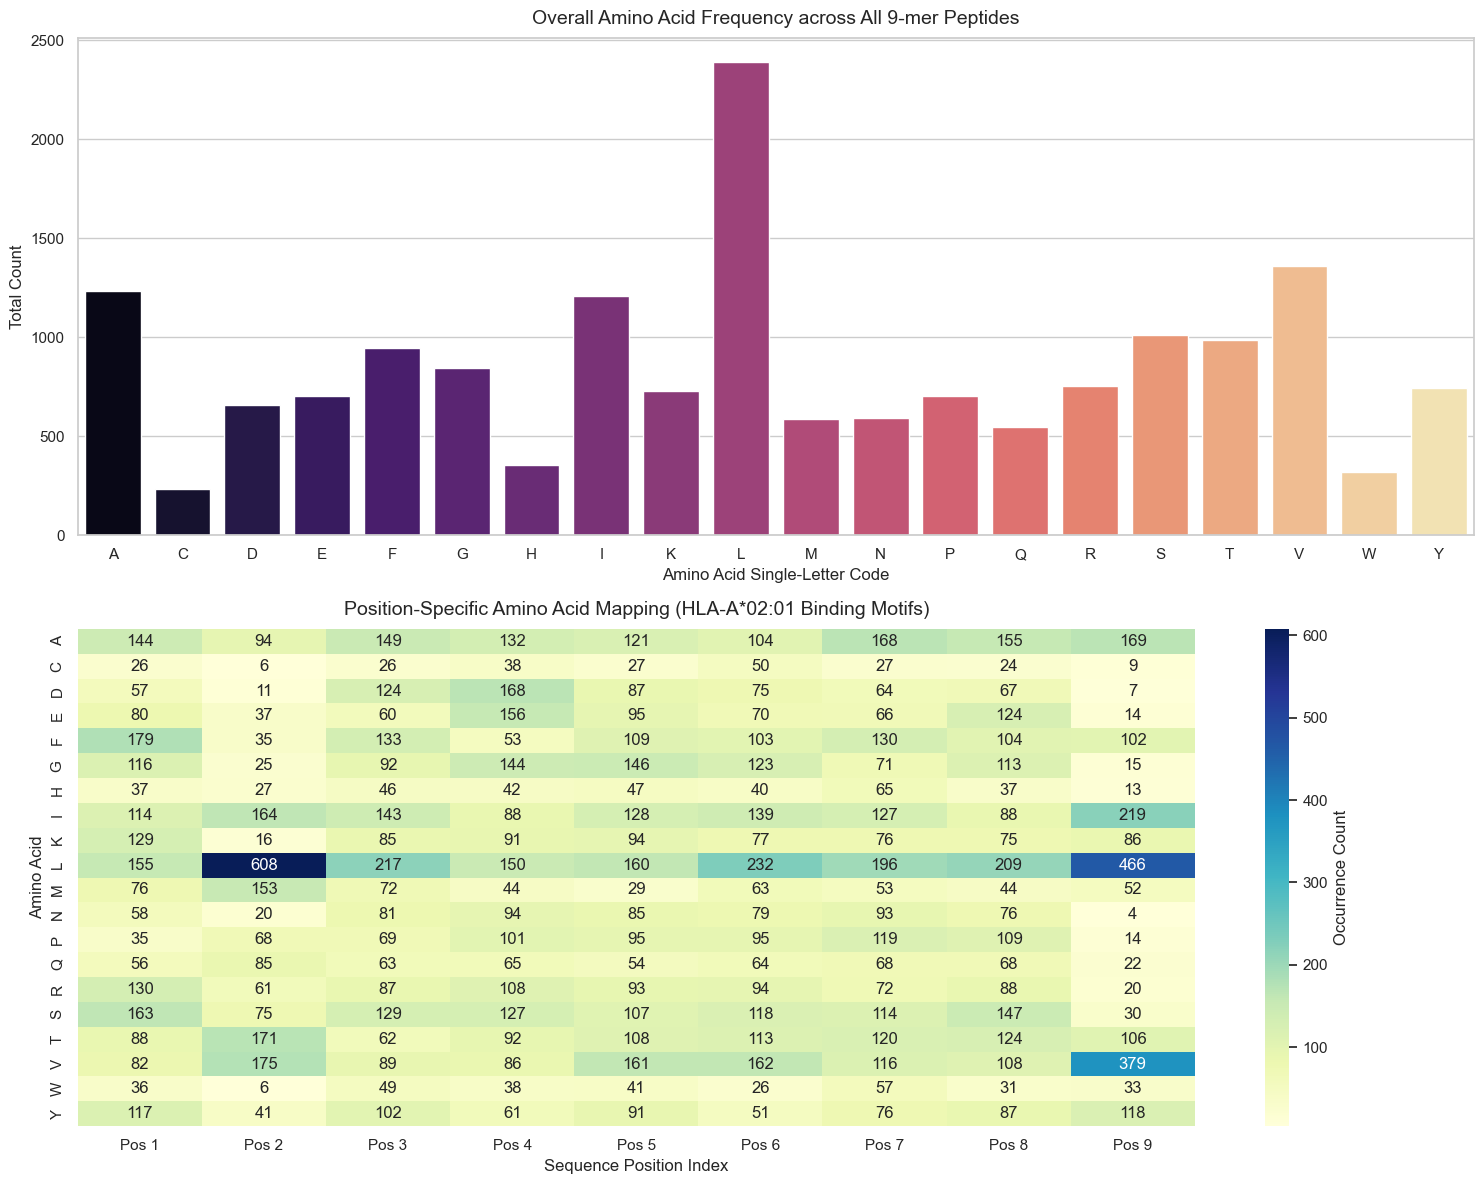

In [94]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(15, 12))
all_peptides_string = "".join(df_final['Sequence'])
aa_counts = pd.Series(list(all_peptides_string)).value_counts().sort_index()

sns.barplot(x=aa_counts.index, y=aa_counts.values, ax=axes[0], palette="magma")
axes[0].set_title('Overall Amino Acid Frequency across All 9-mer Peptides', fontsize=14, pad=10)
axes[0].set_xlabel('Amino Acid Single-Letter Code', fontsize=12)
axes[0].set_ylabel('Total Count', fontsize=12)

AMINO_ACIDS = sorted('ACDEFGHIKLMNPQRSTVWY')
position_matrix = np.zeros((len(AMINO_ACIDS), 9))

for pos in range(9):
    chars_at_pos = df_final['Sequence'].str[pos]
    counts = chars_at_pos.value_counts()
    for aa_idx, aa in enumerate(AMINO_ACIDS):
        position_matrix[aa_idx, pos] = counts.get(aa, 0)
        
heatmap_df = pd.DataFrame(position_matrix, index=AMINO_ACIDS, columns=[f'Pos {i+1}' for i in range(9)])

sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1], cbar_kws={'label': 'Occurrence Count'})
axes[1].set_title('Position-Specific Amino Acid Mapping (HLA-A*02:01 Binding Motifs)', fontsize=14, pad=10)
axes[1].set_xlabel('Sequence Position Index', fontsize=12)
axes[1].set_ylabel('Amino Acid', fontsize=12)

plt.tight_layout()
plt.show()

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [97]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

In [98]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [112]:
new_peptide = "RKKRKKRKK" 

clean_peptide = new_peptide.strip().upper()
if len(clean_peptide) != 9:
    print(f"Error: Sequence must be exactly 9 amino acids long. Your input length is {len(clean_peptide)}.")
else:
    # Check for non-standard amino acid characters
    invalid_chars = [aa for aa in clean_peptide if aa not in AMINO_ACIDS]
    if invalid_chars:
        print(f"Error: Invalid characters detected: {set(invalid_chars)}. Please use standard amino acids.")
    else:
        # 4. Transform using custom one-hot function
        encoded_sample = one_hot_encode_peptide(clean_peptide)
        
        # Reshape to a 2D array since the model expects shape: (1, 180)
        encoded_sample = encoded_sample.reshape(1, -1)
        
        # 5. Make predictions
        predicted_class = model.predict(encoded_sample)[0]
        predicted_probability = model.predict_proba(encoded_sample)[0][1]
        
        # 6. Display the final results
        print(f"================ INFERENCE DEMO ================")
        print(f"Input Peptide Sequence: {clean_peptide}")
        if predicted_class == 1:
            print(f"Result:       BINDER to HLA-A*02:01")
        else:
            print(f"Result:       NON-BINDER to HLA-A*02:01")
            
        print(f"Confidence:   {predicted_probability * 100:.2f}% Binding Probability")

================ INFERENCE DEMO ================
Input Peptide Sequence: RKKRKKRKK
Result:       NON-BINDER to HLA-A*02:01
Confidence:   0.01% Binding Probability


In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
import numpy as np

In [100]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [101]:
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

In [102]:
rmse = np.sqrt(mean_squared_error(y_test, y_prob))

In [103]:
print("================ MODEL EVALUATION ================")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"RMSE:      {rmse:.4f}")

================ MODEL EVALUATION ================
Precision: 0.7260
Recall:    0.8548
F1-Score:  0.7852
RMSE:      0.3340


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

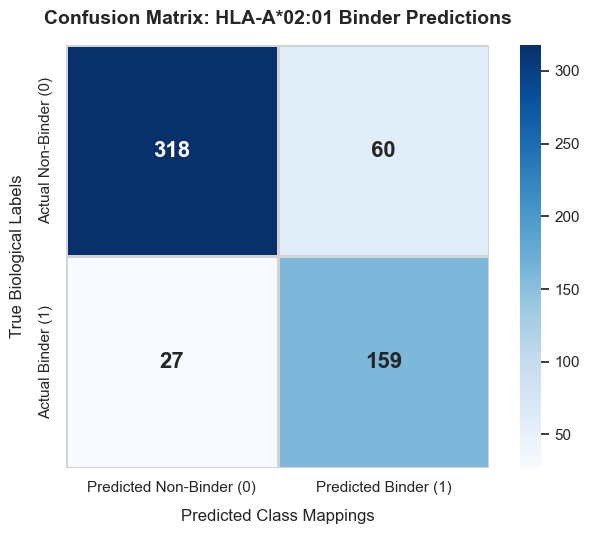

In [111]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5.5))
sns.set_theme(style="white")
sns.heatmap(
    cm,
    annot=True,              # Display the actual counts inside the squares
    fmt='d',                 # Format counts as regular integers
    cmap='Blues',            # Use a clean blue color gradient
    cbar=True,               # Include the color magnitude bar
    square=True,             # Keep the cells perfectly square
    annot_kws={'size': 16, 'weight': 'bold'}, # Make the internal numbers large and bold
    linewidths=1,            # Add subtle grid lines between cells
    linecolor='lightgray'
)
plt.title('Confusion Matrix: HLA-A*02:01 Binder Predictions', fontsize=14, pad=15, weight='bold')
plt.xlabel('Predicted Class Mappings', fontsize=12, labelpad=10)
plt.ylabel('True Biological Labels', fontsize=12, labelpad=10)

# 5. Customize the axis tick positions to show clear readable terms
plt.xticks([0.5, 1.5], ['Predicted Non-Binder (0)', 'Predicted Binder (1)'], fontsize=11)
plt.yticks([0.5, 1.5], ['Actual Non-Binder (0)', 'Actual Binder (1)'], fontsize=11, va='center')

# Show the plot smoothly
plt.tight_layout()
plt.show()

In [115]:
!pip install Gradio

   ---------------------------------------- 0.0/19.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.7 MB ? eta -:--:--
    --------------------------------------- 0.3/19.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.7 MB 1.5 MB/s eta 0:00:13
   ---- ----------------------------------- 2.1/19.7 MB 3.2 MB/s eta 0:00:06
   ------ --------------------------------- 3.4/19.7 MB 4.5 MB/s eta 0:00:04
   ------ --------------------------------- 3.4/19.7 MB 4.5 MB/s eta 0:00:04
   ---------- ----------------------------- 5.0/19.7 MB 4.0 MB/s eta 0:00:04
   ------------- -------------------------- 6.6/19.7 MB 4.5 MB/s eta 0:00:03
   ---------------- ----------------------- 8.1/19.7 MB 5.0 MB/s eta 0:00:03
   ---------------- ----------------------- 8.1/19.7 MB 5.0 MB/s eta 0:00:03
   ------------------ --------------------- 9.2/19.7 MB 4.4 MB/s eta 0:00:03
   ------------------- -------------------- 9.7/19.7 MB 4.0 MB/s eta 0:00:03
   -----------------

In [130]:
import gradio as gr
import numpy as np
import random
import re

PEPTIDE_POOL = [
    "GILGFVFTL", "LLFGYPVYV", "ALWGFFPVL", "SLYNTVATL", "NLVPMVATV", 
    "GLCTLVAML", "TLDSYLVNV", "YLLPAIVHI", "MLDLQPETT", "FLPSDFFPSV",
    "AAAAAAAAA", "GKGGFVFTL", "GILGFVFTD", "RKKRKKRKK", "PPPPPPLPP", 
    "WVVVVVVVW", "DDEEDDEED", "QQQQQQQQQ", "SSTTSSGGS", "KKKKKKKKK"
]

def get_random_peptide():
    return random.choice(PEPTIDE_POOL)[:9]

def predict_peptide_binding(sequence):
    clean_seq = sequence.strip().upper()
    
    if len(clean_seq) != 9:
        return f" Validation Error: The sequence must be exactly 9 characters long. Your input length is {len(clean_seq)}."
    
    if not re.match(r"^[ACDEFGHIKLMNPQRSTVWY]+$", clean_seq):
        invalid_chars = [char for char in clean_seq if char not in "ACDEFGHIKLMNPQRSTVWY"]
        return (
            f" Biological Validation Error: Invalid characters detected: {set(invalid_chars)}.\n"
            f"An eligible sequence must consist strictly of the 20 standard amino acids used in protein synthesis."
        )
    
    encoded_vector = one_hot_encode_peptide(clean_seq).reshape(1, -1)
    prediction = model.predict(encoded_vector)[0]
    probability = model.predict_proba(encoded_vector)[0][1]
    
    status = "**BINDER**" if prediction == 1 else "**NON-BINDER**"
    
    return (
        f"### Prediction Result for **{clean_seq}**:\n"
        f"**Classification Decision:** {status}\n\n"
        f"**Binding Probability Score:** {probability * 100:.2f}%"
    )

custom_css = """
body, html, .gradio-container {
    background-color: #0b0f19 !important; 
}
#main-container {
    max-width: 800px;
    margin: 40px auto !important;
    padding: 30px;
    background-color: #ffffff !important;
    border-radius: 12px;
    box-shadow: 0 10px 30px rgba(0, 0, 0, 0.5);
}
#main-container h1, #main-container p, #main-container span {
    color: #111827 !important;
}
"""

with gr.Blocks() as app:
    
    with gr.Column(elem_id="main-container"):
        gr.Markdown("# HLA-A*02:01 Peptide Binder Predictor")
        gr.Markdown(
            "Type a 9-mer epitope sequence below, or click the button to pull a random verified "
            "sequence from our biological sample pool."
        )
        
        with gr.Row():
            with gr.Column():
                input_seq = gr.Textbox(
                    lines=1, 
                    placeholder="Enter a 9-mer peptide (e.g., GILGFVFTL)...", 
                    label="Input Peptide Sequence"
                )
                
                with gr.Row():
                    random_btn = gr.Button(" Generate Random Peptide", variant="secondary")
                    submit_btn = gr.Button(" Run Prediction", variant="primary")
                    
            with gr.Column():
                output_md = gr.Markdown(label="Prediction Output")
                
        random_btn.click(fn=get_random_peptide, inputs=None, outputs=input_seq)
        submit_btn.click(fn=predict_peptide_binding, inputs=input_seq, outputs=output_md)
        input_seq.submit(fn=predict_peptide_binding, inputs=input_seq, outputs=output_md)
        
        gr.Examples(
            examples=[["GILGFVFTL"], ["GKGGFVFTL"], ["AAAAAAAAA"]],
            inputs=input_seq
        )

app.launch(css=custom_css)

* Running on local URL:  http://127.0.0.1:7872
* To create a public link, set `share=True` in `launch()`.
